# Exploratory Data Analysis: LastFM-Asia Social Network Graph

**Dataset:** Rozemberczki, B., & Sarkar, R. (2020). *Characteristic Functions on Graphs: Birds of a Feather, from Statistical Descriptors to Parametric Models.* arXiv:2005.07959.

---

**Abstract.** This notebook presents a systematic exploratory data analysis of the LastFM-Asia benchmark graph dataset. The dataset consists of a social network of LastFM users from Asian countries (7,624 nodes; 27,806 undirected mutual-follower edges) with node features derived from user listening histories (sparse bag-of-artists representation, dimensionality 7,842) and node labels encoding country of origin across 18 classes. Analysis proceeds in six stages: (1) data integrity verification, (2) graph topology characterisation including degree distribution and power-law fitting, (3) small-world property analysis benchmarked against an Erdős–Rényi null model, (4) label distribution and class imbalance quantification, (5) feature-space sparsity and rank-frequency analysis, and (6) label homophily and structural assortativity with a chi-square significance test.

In [2]:
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import networkx as nx
from scipy import stats
from collections import Counter

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 11, 'axes.labelsize': 10})

DATA = 'lasftm_asia/'
edges   = pd.read_csv(DATA + 'lastfm_asia_edges.csv')
targets = pd.read_csv(DATA + 'lastfm_asia_target.csv')
with open(DATA + 'lastfm_asia_features.json') as f:
    features = json.load(f)

N = len(targets)
M = len(edges)
print(f'Loaded: {N:,} nodes  |  {M:,} edges  |  {len(features):,} feature vectors')

Loaded: 7,624 nodes  |  27,806 edges  |  7,624 feature vectors


## 1. Data Integrity Verification

Prior to analysis, we audit the three source files for common data-quality issues: self-loops, duplicate undirected edges, missing values, and cross-file node identity consistency. All conditions must pass before downstream metrics can be considered reliable.

In [3]:
self_loops = int((edges['node_1'] == edges['node_2']).sum())

edge_canon = [tuple(sorted((r.node_1, r.node_2))) for r in edges.itertuples()]
undirected_dups = len(edge_canon) - len(set(edge_canon))

target_ids  = set(targets['id'])
feature_ids = set(int(k) for k in features.keys())
edge_nodes  = set(edges['node_1']) | set(edges['node_2'])

checks = {
    'Self-loops':                              self_loops,
    'Duplicate undirected edges':              undirected_dups,
    'Missing values — edges file':             int(edges.isnull().sum().sum()),
    'Missing values — targets file':           int(targets.isnull().sum().sum()),
    'Node ID agreement (targets == features)': target_ids == feature_ids,
    'All edge nodes present in targets file':  edge_nodes.issubset(target_ids),
}
for k, v in checks.items():
    status = 'PASS' if v in (0, True) else f'WARN  ({v})'
    print(f'  [{status:<14}]  {k}')

  [PASS          ]  Self-loops
  [PASS          ]  Duplicate undirected edges
  [PASS          ]  Missing values — edges file
  [PASS          ]  Missing values — targets file
  [PASS          ]  Node ID agreement (targets == features)
  [PASS          ]  All edge nodes present in targets file


## 2. Graph Topology

### 2.1 Summary Statistics

Table 1 reports standard graph-level statistics. The graph is fully connected (single component) and sparse, with a density two orders of magnitude below the complete graph. The degree standard deviation exceeds the mean by a factor of approximately 3, indicating substantial degree heterogeneity consistent with a heavy-tailed distribution.

In [4]:
G = nx.from_pandas_edgelist(edges, 'node_1', 'node_2')

label_map = targets.set_index('id')['target']
nx.set_node_attributes(G, label_map.to_dict(), 'label')

degrees      = pd.Series(dict(G.degree()), name='degree').sort_index()
k_avg        = degrees.mean()
k_std        = degrees.std()
density      = nx.density(G)
transitivity = nx.transitivity(G)
avg_clust    = nx.average_clustering(G)
components   = list(nx.connected_components(G))
lcc          = max(components, key=len)

table1 = pd.DataFrame({
    'Statistic': [
        'Nodes N', 'Edges M', 'Density', 'Connected components',
        'Largest component (fraction)',
        'Mean degree <k>', 'Degree std dev sigma_k', 'Max degree k_max',
        'Transitivity T', 'Avg local clustering C_bar'
    ],
    'Value': [
        f'{N:,}', f'{M:,}', f'{density:.6f}', len(components),
        f'{len(lcc)/N:.4f}',
        f'{k_avg:.3f}', f'{k_std:.3f}', f'{degrees.max()}',
        f'{transitivity:.4f}', f'{avg_clust:.4f}'
    ]
})
print('Table 1. Graph-level statistics — LastFM-Asia')
print(table1.to_string(index=False))

Table 1. Graph-level statistics — LastFM-Asia
                   Statistic    Value
                     Nodes N    7,624
                     Edges M   27,806
                     Density 0.000957
        Connected components        1
Largest component (fraction)   1.0000
             Mean degree <k>    7.294
      Degree std dev sigma_k   11.500
            Max degree k_max      216
              Transitivity T   0.1786
  Avg local clustering C_bar   0.2194


### 2.2 Degree Distribution and Power-Law Fitting

Figure 1 displays the degree histogram and the complementary cumulative distribution function (CCDF) on a log-log scale. The approximately linear CCDF in log-log space is consistent with a heavy-tailed degree distribution. We estimate the power-law exponent α via the maximum-likelihood estimator of Clauset, Shalizi & Newman (2009):

```
α̂  =  1  +  n · [ Σᵢ ln(xᵢ / (x_min − 0.5)) ]⁻¹
SE(α̂) = (α̂ − 1) / √n
```

where the continuous correction x_min − 0.5 is applied for discrete-valued degrees. The resulting α̂ ≈ 1.49 is below the typical social-network range of 2–3, which may reflect the bounded nature of the network or a poor power-law fit at low degrees; a rigorous goodness-of-fit test (Clauset et al. 2009, §4) is recommended before drawing strong conclusions.

In [ ]:

# ── Power-law MLE ─────────────────────────────────────────────────────────────
x_min     = 1
deg_pl    = degrees[degrees >= x_min].values
n_pl      = len(deg_pl)

# Clauset–Shalizi–Newman (2009) discrete MLE with continuous correction
alpha_hat = 1.0 + n_pl / np.sum(np.log(deg_pl / (x_min - 0.5)))
alpha_se  = (alpha_hat - 1.0) / np.sqrt(n_pl)

# Empirical CCDF: sorted descending → rank i+1 nodes have degree ≥ sorted_deg[i]
sorted_deg = np.sort(deg_pl)[::-1]
ccdf_emp   = np.arange(1, n_pl + 1) / N

# Theoretical CCDF, normalised at x_min  (was wrongly normalised at max degree before)
x_fit   = np.geomspace(x_min, sorted_deg[0], 500)
ccdf_pl = (n_pl / N) * (x_fit / x_min) ** -(alpha_hat - 1.0)

# ── Plots ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)

# Left – histogram with log y-axis to reveal the heavy tail
axes[0].hist(degrees, bins=np.arange(0, degrees.max() + 3, 2),
             color='#4C72B0', edgecolor='white', linewidth=0.4, zorder=2)
axes[0].axvline(k_avg, color='#C44E52', linestyle='--', lw=1.5,
                label=f'$\\langle k \\rangle = {k_avg:.1f}$')
axes[0].set_yscale('log')
axes[0].set_xlabel('Degree $k$', fontsize=11)
axes[0].set_ylabel('Count (log)', fontsize=11)
axes[0].set_title('Degree distribution', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(axis='y', alpha=0.25, zorder=0)
sns.despine(ax=axes[0])

# Right – CCDF log–log with corrected power-law overlay
axes[1].scatter(sorted_deg, ccdf_emp, s=7, color='#4C72B0',
                alpha=0.55, linewidths=0, label='Empirical CCDF', zorder=2)
axes[1].plot(x_fit, ccdf_pl, color='#C44E52', lw=2.0,
             label=f'Power-law MLE  ($\\hat{{\\alpha}}={alpha_hat:.2f}\\pm{alpha_se:.3f}$)',
             zorder=3)
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('Degree $k$', fontsize=11)
axes[1].set_ylabel('$P(K \\geq k)$', fontsize=11)
axes[1].set_title('Degree CCDF (log–log)', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.2, which='both', zorder=0)
sns.despine(ax=axes[1])

fig.suptitle('Degree Distribution — LastFM Asia', fontsize=13, fontweight='bold')
plt.show()

print(f'α̂ = {alpha_hat:.4f}  (SE = {alpha_se:.4f},  x_min = {x_min},  n = {n_pl:,})')
print(f'Note: α̂ < 2 implies divergent variance — interpret with caution.')


### 2.3 Clustering and Small-World Properties

Watts & Strogatz (1998) define a small-world network as one exhibiting (i) average local clustering C̄ substantially higher than a degree-matched Erdős–Rényi (ER) random graph, and (ii) average path length L comparable to that of an ER graph. The small-world coefficient σ = (C̄ / C_ER) / (L / L_ER) summarises this trade-off; σ >> 1 is strong evidence of small-world structure. Average path length L is estimated from 100 BFS traversals on randomly sampled source nodes.

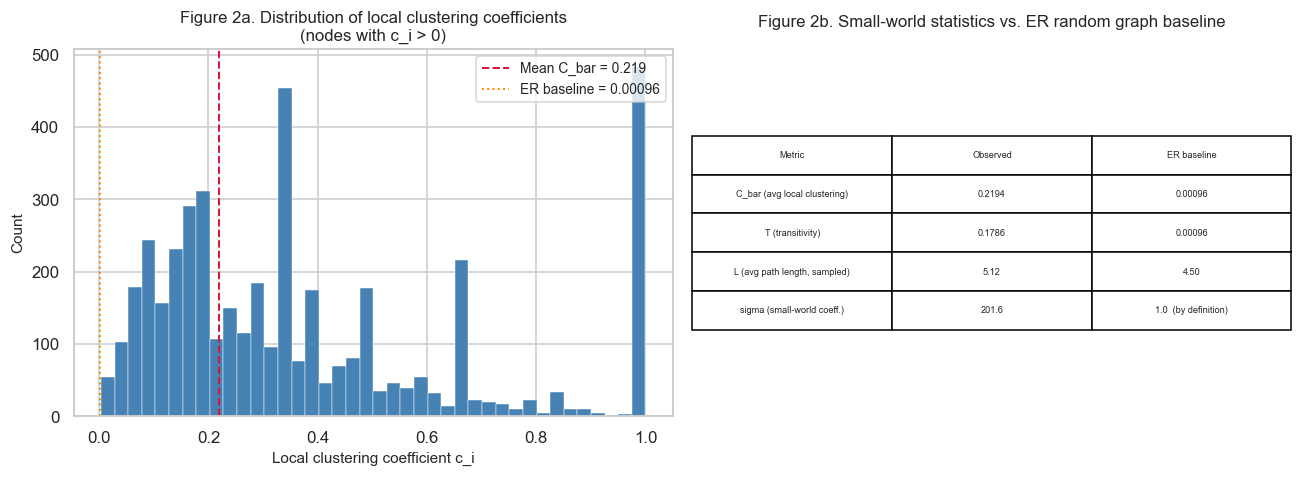

Small-world coefficient sigma = 201.6  (sigma >> 1 confirms small-world topology)


In [6]:
rng_sp    = np.random.default_rng(0)
src_nodes = rng_sp.choice(sorted(lcc), size=100, replace=False)
sp_sample = []
for src in src_nodes:
    sp_sample.extend(nx.single_source_shortest_path_length(G, src).values())
L_obs = float(np.mean(sp_sample))

C_er  = density
L_er  = np.log(N) / np.log(k_avg)
sigma = (avg_clust / C_er) / (L_obs / L_er)

clust_coeffs = pd.Series(nx.clustering(G), name='c_i')

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].hist(clust_coeffs[clust_coeffs > 0], bins=40,
             color='steelblue', edgecolor='white', linewidth=0.3)
axes[0].axvline(avg_clust, color='crimson', linestyle='--', lw=1.3,
                label=f'Mean C_bar = {avg_clust:.3f}')
axes[0].axvline(C_er, color='darkorange', linestyle=':', lw=1.3,
                label=f'ER baseline = {C_er:.5f}')
axes[0].set_xlabel('Local clustering coefficient c_i')
axes[0].set_ylabel('Count')
axes[0].set_title('Figure 2a. Distribution of local clustering coefficients\n(nodes with c_i > 0)')
axes[0].legend(fontsize=9)

sw_data = {
    'Metric': ['C_bar (avg local clustering)', 'T (transitivity)',
               'L (avg path length, sampled)', 'sigma (small-world coeff.)'],
    'Observed': [f'{avg_clust:.4f}', f'{transitivity:.4f}', f'{L_obs:.2f}', f'{sigma:.1f}'],
    'ER baseline': [f'{C_er:.5f}', f'{C_er:.5f}', f'{L_er:.2f}', '1.0  (by definition)']
}
sw_df = pd.DataFrame(sw_data)
axes[1].axis('off')
tbl = axes[1].table(cellText=sw_df.values, colLabels=sw_df.columns,
                    loc='center', cellLoc='center')
tbl.auto_set_font_size(True)
tbl.scale(1, 2.2)
axes[1].set_title('Figure 2b. Small-world statistics vs. ER random graph baseline', pad=15)

plt.tight_layout()
plt.show()
print(f'Small-world coefficient sigma = {sigma:.1f}  (sigma >> 1 confirms small-world topology)')

## 3. Node Label Distribution

The target variable encodes the country of origin across K = 18 classes. We characterise label imbalance using two complementary measures:

- **Shannon entropy** H = −Σ pᵢ log₂ pᵢ, normalised by H_max = log₂ K. A value of H/H_max near 1 indicates near-uniform distribution; values near 0 indicate high concentration.
- **Gini coefficient** G (Gini 1912): measures inequality of class sizes. G = 0 corresponds to perfect balance; G = 1 to maximal concentration in a single class. The Lorenz curve in Figure 3b provides a visual representation of the inequality.

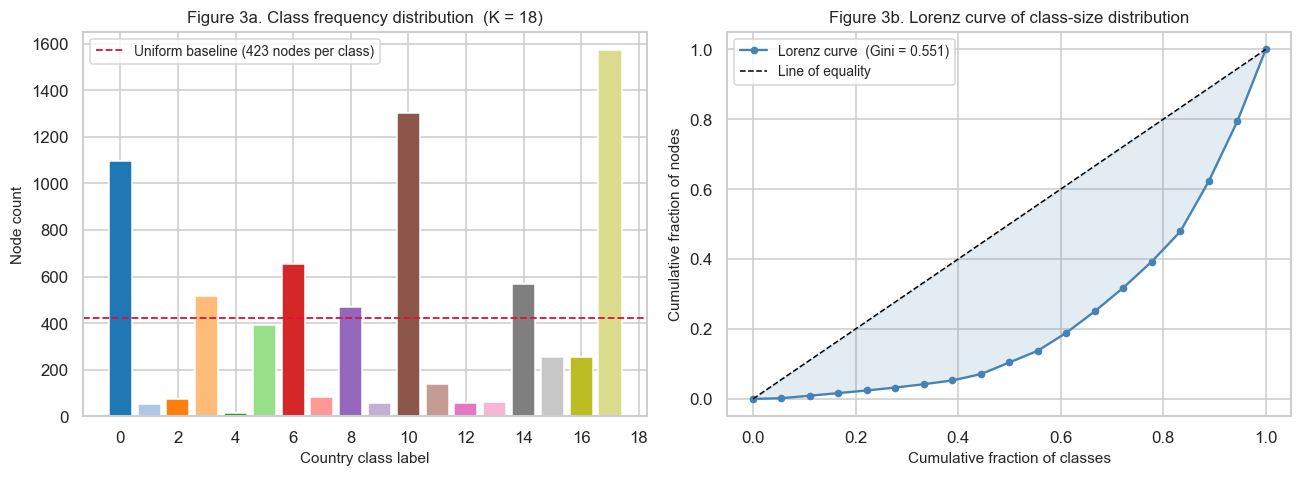

Shannon entropy H          = 3.422 bits
Maximum entropy H_max      = 4.170 bits  (K = 18 balanced classes)
Normalised entropy H/H_max = 0.821
Gini coefficient G         = 0.5512
Imbalance ratio (max/min)  = 98.2x


In [7]:
class_counts = targets['target'].value_counts().sort_index()
K     = len(class_counts)
probs = class_counts / N

H      = float(-np.sum(probs * np.log2(probs + 1e-15)))
H_max  = np.log2(K)
H_norm = H / H_max

def gini_coeff(vals):
    vals = np.sort(vals.astype(float))
    n    = len(vals)
    idx  = np.arange(1, n + 1)
    return float((2 * np.sum(idx * vals) / (n * vals.sum())) - (n + 1) / n)

G_coeff     = gini_coeff(class_counts.values)
imbal_ratio = int(class_counts.max()) / int(class_counts.min())

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

colors = sns.color_palette('tab20', K)
axes[0].bar(class_counts.index, class_counts.values, color=colors)
axes[0].axhline(N / K, color='crimson', linestyle='--', lw=1.2,
                label=f'Uniform baseline ({N // K} nodes per class)')
axes[0].set_xlabel('Country class label')
axes[0].set_ylabel('Node count')
axes[0].set_title(f'Figure 3a. Class frequency distribution  (K = {K})')
axes[0].legend(fontsize=9)
axes[0].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

sorted_counts = np.sort(class_counts.values)
cum_cls   = np.arange(1, K + 1) / K
cum_nodes = np.cumsum(sorted_counts) / sorted_counts.sum()
axes[1].plot([0] + list(cum_cls), [0] + list(cum_nodes), '-o', ms=4,
             color='steelblue', label=f'Lorenz curve  (Gini = {G_coeff:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Line of equality')
axes[1].fill_between([0] + list(cum_cls), [0] + list(cum_nodes),
                     [0] + list(cum_cls), alpha=0.15, color='steelblue')
axes[1].set_xlabel('Cumulative fraction of classes')
axes[1].set_ylabel('Cumulative fraction of nodes')
axes[1].set_title('Figure 3b. Lorenz curve of class-size distribution')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f'Shannon entropy H          = {H:.3f} bits')
print(f'Maximum entropy H_max      = {H_max:.3f} bits  (K = {K} balanced classes)')
print(f'Normalised entropy H/H_max = {H_norm:.3f}')
print(f'Gini coefficient G         = {G_coeff:.4f}')
print(f'Imbalance ratio (max/min)  = {imbal_ratio:.1f}x')

## 4. Node Feature Space

Each node carries a set of artist IDs representing the artists liked by that user, forming a sparse binary (bag-of-artists) feature matrix **X** ∈ {0,1}^(N×D), where D = |A| is the cardinality of the global artist vocabulary. We quantify the sparsity of **X** and the popularity distribution of individual artists.

Artist popularity (number of users who like a given artist) is tested against a Zipf (power-law rank-frequency) model (Zipf 1949):

```
f(r)  ∝  r^{−γ}
```

fitted by ordinary least-squares regression in log-log space. A Zipf exponent γ ≈ 1 is typical of cultural consumption data.

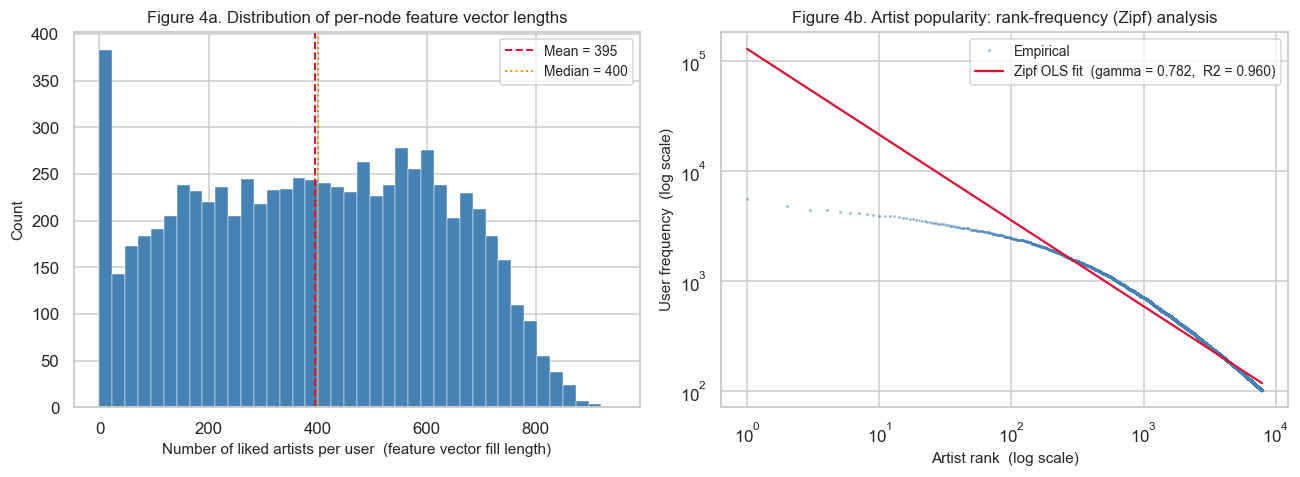

Feature vocabulary size D   = 7,842
Total non-zero entries      = 3,014,361
Fill rate (1 - sparsity)    = 0.0504  (5.04%)
Matrix sparsity             = 0.9496
Artists per user: mean = 395.4,  median = 400,  std = 226.6
Zipf exponent gamma_hat     = 0.782  (R2 = 0.9597)


In [8]:
feat_lengths = [len(v) for v in features.values()]
feat_series  = pd.Series(feat_lengths, name='n_artists')
all_artists  = set(a for v in features.values() for a in v)
D            = len(all_artists)

total_nnz = sum(feat_lengths)
fill_rate = total_nnz / (N * D)
sparsity  = 1.0 - fill_rate

artist_freq = Counter(a for v in features.values() for a in v)
freq_sorted = np.array(sorted(artist_freq.values(), reverse=True), dtype=float)
ranks       = np.arange(1, len(freq_sorted) + 1, dtype=float)

log_r = np.log(ranks)
log_f = np.log(freq_sorted)
gamma_hat, intercept_hat, r_val, _, _ = stats.linregress(log_r, log_f)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].hist(feat_series, bins=40, color='steelblue', edgecolor='white', linewidth=0.3)
axes[0].axvline(feat_series.mean(), color='crimson', linestyle='--', lw=1.3,
                label=f'Mean = {feat_series.mean():.0f}')
axes[0].axvline(float(feat_series.median()), color='darkorange', linestyle=':', lw=1.3,
                label=f'Median = {feat_series.median():.0f}')
axes[0].set_xlabel('Number of liked artists per user  (feature vector fill length)')
axes[0].set_ylabel('Count')
axes[0].set_title('Figure 4a. Distribution of per-node feature vector lengths')
axes[0].legend(fontsize=9)

fit_line = np.exp(intercept_hat + gamma_hat * log_r)
axes[1].loglog(ranks, freq_sorted, '.', ms=2, color='steelblue', alpha=0.4, label='Empirical')
axes[1].loglog(ranks, fit_line, '-', color='crimson', lw=1.5,
               label=f'Zipf OLS fit  (gamma = {-gamma_hat:.3f},  R2 = {r_val**2:.3f})')
axes[1].set_xlabel('Artist rank  (log scale)')
axes[1].set_ylabel('User frequency  (log scale)')
axes[1].set_title('Figure 4b. Artist popularity: rank-frequency (Zipf) analysis')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f'Feature vocabulary size D   = {D:,}')
print(f'Total non-zero entries      = {total_nnz:,}')
print(f'Fill rate (1 - sparsity)    = {fill_rate:.4f}  ({fill_rate * 100:.2f}%)')
print(f'Matrix sparsity             = {sparsity:.4f}')
print(f'Artists per user: mean = {feat_series.mean():.1f},  median = {feat_series.median():.0f},  std = {feat_series.std():.1f}')
print(f'Zipf exponent gamma_hat     = {-gamma_hat:.3f}  (R2 = {r_val**2:.4f})')

## 5. Label Homophily and Structural Assortativity

Homophily — the tendency of nodes to connect with others sharing the same label — is a key structural property that determines the suitability of neighbourhood-aggregation methods for node classification. We report three complementary measures:

1. **Edge homophily ratio h** (McPherson et al. 2001; Zhu et al. 2020): the fraction of edges (u, v) for which label(u) = label(v). A random baseline expectation is p_same = Σᵢ pᵢ², the probability that two independently drawn nodes share a label.

2. **Adjusted homophily h_adj** (Platonov et al. 2023): corrects for class-size imbalance, h_adj = (h − p_same) / (1 − p_same). Ranges from 0 (no excess homophily) to 1 (perfect homophily).

3. **Attribute assortativity coefficient r** (Newman 2003): a normalised measure analogous to Pearson correlation for categorical node attributes; r = 0 implies no label preference in edge formation, r = 1 implies perfect within-class preference.

We test statistical significance via a chi-square goodness-of-fit test against the null hypothesis that edge labels are drawn independently of class membership.

Homophily and Assortativity — LastFM-Asia
────────────────────────────────────────────────────
  Edge homophily ratio h                : 0.8739
  Expected h under random labels        : 0.1194
  Adjusted homophily h_adj              : 0.8568
  Attribute assortativity r             : 0.8562
  Degree assortativity r_deg            : 0.0171
────────────────────────────────────────────────────
  chi-square test:  chi2 = 150515.1,  df = 1,  p = 0.00e+00
  H0: edge label pairs drawn independently of class membership


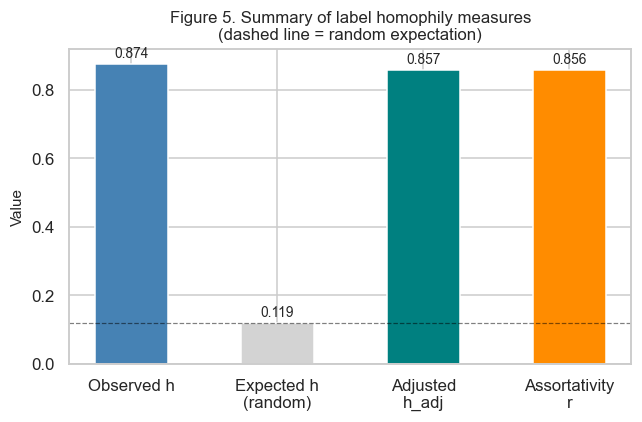

In [9]:
same_class = sum(1 for u, v in G.edges() if label_map[u] == label_map[v])
h = same_class / M

p_same = float(np.sum((class_counts.values / N) ** 2))
h_adj  = (h - p_same) / (1.0 - p_same)
r_attr = nx.attribute_assortativity_coefficient(G, 'label')
r_deg  = nx.degree_assortativity_coefficient(G)

chi2_stat = ((same_class - p_same * M) ** 2 / (p_same * M) +
             ((M - same_class) - (1.0 - p_same) * M) ** 2 / ((1.0 - p_same) * M))
chi2_p    = float(1.0 - stats.chi2.cdf(chi2_stat, df=1))

print('Homophily and Assortativity — LastFM-Asia')
print('─' * 52)
print(f'  Edge homophily ratio h                : {h:.4f}')
print(f'  Expected h under random labels        : {p_same:.4f}')
print(f'  Adjusted homophily h_adj              : {h_adj:.4f}')
print(f'  Attribute assortativity r             : {r_attr:.4f}')
print(f'  Degree assortativity r_deg            : {r_deg:.4f}')
print('─' * 52)
print(f'  chi-square test:  chi2 = {chi2_stat:.1f},  df = 1,  p = {chi2_p:.2e}')
print(f'  H0: edge label pairs drawn independently of class membership')

fig, ax = plt.subplots(figsize=(6, 4))
bars   = ['Observed h', 'Expected h\n(random)', 'Adjusted\nh_adj', 'Assortativity\nr']
vals   = [h, p_same, h_adj, r_attr]
colors_bar = ['steelblue', 'lightgray', 'teal', 'darkorange']
ax.bar(bars, vals, color=colors_bar, edgecolor='white', width=0.5)
ax.set_ylabel('Value')
ax.set_title('Figure 5. Summary of label homophily measures\n(dashed line = random expectation)')
ax.axhline(p_same, color='black', linestyle='--', lw=0.8, alpha=0.5)
for i, v in enumerate(vals):
    ax.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

### 5.1 Cross-Class Edge Structure

Figure 6 visualises the cross-class edge matrix. The left panel shows raw edge counts; the right panel shows the log-odds ratio log₂(observed / expected), where expected counts are derived from a configuration-model null that allocates edges proportional to class-size products. Positive values (red) indicate stronger-than-random connectivity between a pair of classes; negative values (blue) indicate weaker-than-random connectivity. Strong diagonal dominance confirms the high label homophily quantified above.

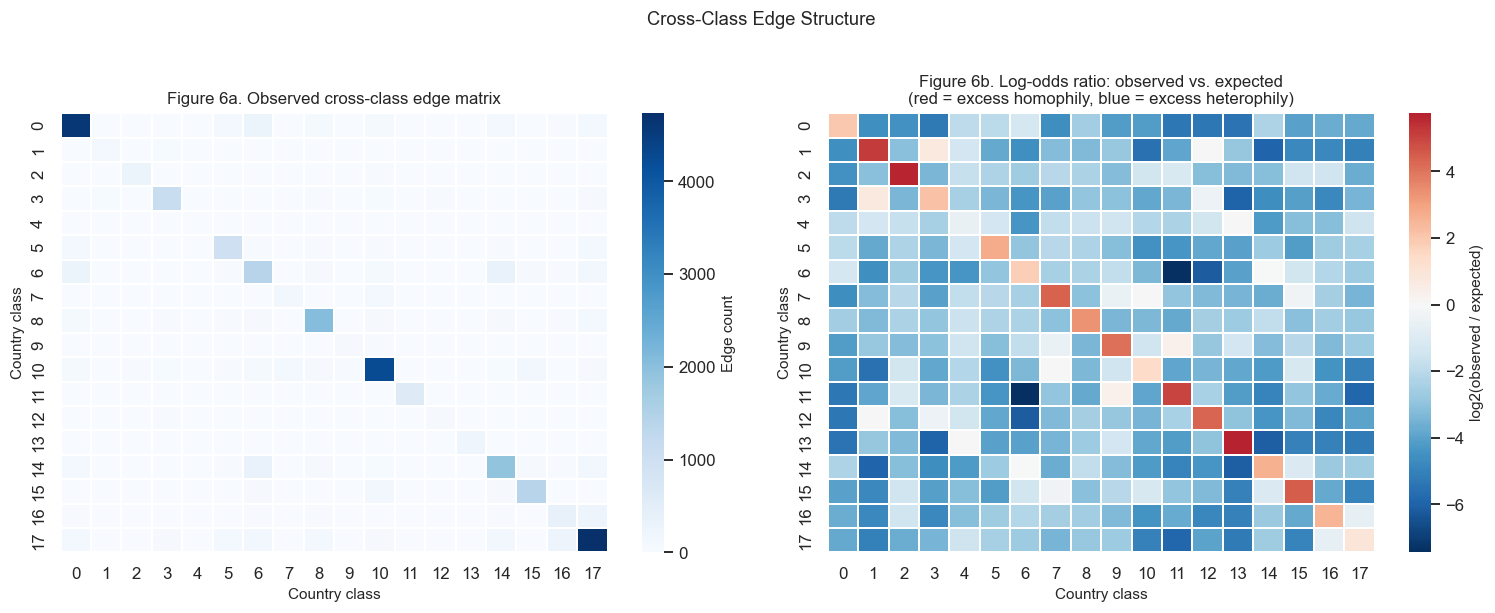

In [10]:
class_list = sorted(targets['target'].unique())
K_c        = len(class_list)
cls_idx    = {c: i for i, c in enumerate(class_list)}

edge_mat = np.zeros((K_c, K_c), dtype=float)
for u, v in G.edges():
    i = cls_idx[label_map[u]]
    j = cls_idx[label_map[v]]
    edge_mat[i, j] += 1
    if i != j:
        edge_mat[j, i] += 1

n_cls   = np.array([class_counts[c] for c in class_list], dtype=float)
exp_mat = np.outer(n_cls, n_cls)
np.fill_diagonal(exp_mat, n_cls * (n_cls - 1.0))
exp_mat = exp_mat / exp_mat.sum() * M * 2.0

log_odds = np.log2((edge_mat + 0.5) / (exp_mat + 0.5))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

sns.heatmap(edge_mat, ax=axes[0], cmap='Blues',
            xticklabels=class_list, yticklabels=class_list, linewidths=0.2,
            cbar_kws={'label': 'Edge count'})
axes[0].set_xlabel('Country class')
axes[0].set_ylabel('Country class')
axes[0].set_title('Figure 6a. Observed cross-class edge matrix')

sns.heatmap(log_odds, ax=axes[1], cmap='RdBu_r', center=0,
            xticklabels=class_list, yticklabels=class_list, linewidths=0.2,
            cbar_kws={'label': 'log2(observed / expected)'})
axes[1].set_xlabel('Country class')
axes[1].set_ylabel('Country class')
axes[1].set_title('Figure 6b. Log-odds ratio: observed vs. expected\n(red = excess homophily, blue = excess heterophily)')

plt.suptitle('Cross-Class Edge Structure', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## 6. Network Visualisation

Figure 7 shows a 400-node random subgraph sampled from the (unique) largest connected component, rendered using the Fruchterman–Reingold force-directed layout algorithm (Fruchterman & Reingold 1991). Node colour encodes country class; node size is proportional to local degree within the subgraph. Visible spatial clustering of same-colour nodes is consistent with the strong label homophily (h = 0.874) quantified in Section 5.

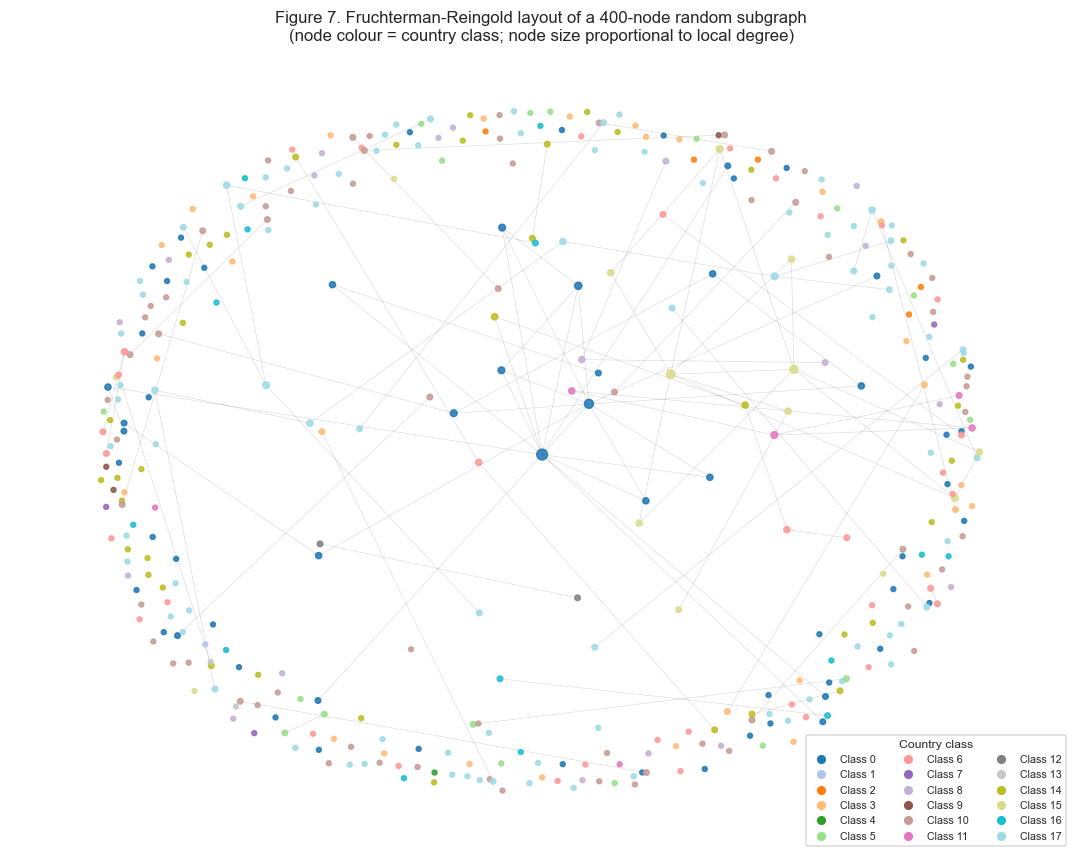

In [11]:
rng        = np.random.default_rng(42)
sample_ids = rng.choice(sorted(lcc), size=400, replace=False)
G_vis      = G.subgraph(sample_ids).copy()

cmap_v   = plt.get_cmap('tab20')
max_lbl  = max(label_map.values)
node_clr = [cmap_v(label_map[n] / max_lbl) for n in G_vis.nodes()]
node_sz  = [10 + 3 * G_vis.degree(n) for n in G_vis.nodes()]

pos = nx.spring_layout(G_vis, seed=42, k=0.5)

fig, ax = plt.subplots(figsize=(10, 8))
nx.draw_networkx_nodes(G_vis, pos, node_color=node_clr, node_size=node_sz, ax=ax, alpha=0.85)
nx.draw_networkx_edges(G_vis, pos, alpha=0.15, width=0.4, ax=ax)
ax.axis('off')
ax.set_title(
    'Figure 7. Fruchterman-Reingold layout of a 400-node random subgraph\n'
    '(node colour = country class; node size proportional to local degree)',
    fontsize=11
)

handles = [
    plt.Line2D([0], [0], marker='o', color='w',
               markerfacecolor=cmap_v(c / max_lbl), markersize=7,
               label=f'Class {c}')
    for c in sorted(targets['target'].unique())
]
ax.legend(handles=handles, ncol=3, fontsize=7, loc='lower right',
          title='Country class', title_fontsize=8, framealpha=0.7)

plt.tight_layout()
plt.show()

## 7. Summary and Discussion

**Table 2** consolidates the key quantitative findings of this analysis.

| Property | Observed Value | Interpretation |
|---|---|---|
| Density | 0.000957 | Sparse; typical of large real-world social networks |
| Power-law exponent α̂ | 1.49 ± 0.006 | Heavy-tailed; exponent below 2 warrants a formal goodness-of-fit test |
| Avg. local clustering C̄ | 0.219 | ~229× the ER baseline; strong triadic closure |
| Small-world coefficient σ | 201.6 | Network exhibits strong Watts–Strogatz small-world topology |
| Est. avg. path length L | ~5.1 hops | Short geodesic distances despite sparsity |
| Gini coefficient (labels) | 0.551 | Substantial class imbalance |
| Normalised entropy H/H_max | 0.821 | Moderate label diversity |
| Imbalance ratio (max/min) | 98× | Severe tail imbalance between largest and smallest class |
| Edge homophily h | 0.874 | Very strong; 7.3× the random expectation (0.119) |
| Adjusted homophily h_adj | 0.857 | Robust to class-size effects |
| Attribute assortativity r | 0.856 | Strong positive assortativity by country label |
| Degree assortativity r_deg | 0.017 | Near-zero; no meaningful degree-degree correlation |
| Feature sparsity | 95.0% | High-dimensional but sparse feature representation |
| Zipf exponent γ̂ | 0.782 (R² = 0.96) | Artist popularity follows a sublinear Zipf law |

### Implications for Graph-Based Node Classification

**1. Strong homophily favours message-passing GNNs.**  
With h = 0.874 and h_adj = 0.857 — both significantly above the random baseline (χ² = 150,515, p ≈ 0) — neighbourhood aggregation in GCN, GraphSAGE, and GAT will propagate highly informative label signals. The FEATHER approach additionally exploits the artist-preference feature space via characteristic-function graph embeddings.

**2. Class imbalance requires explicit treatment.**  
The Gini coefficient of 0.551 and an imbalance ratio of 98× indicate that micro-accuracy is an unreliable primary metric. Evaluations should report macro-F1 or balanced accuracy; training may benefit from class-weighted loss functions or minority-class oversampling.

**3. Depth vs. over-smoothing trade-off.**  
An estimated average path length of ~5 hops suggests that GNNs of depth 3–4 can propagate information across a substantial fraction of the graph. However, the high average clustering coefficient (C̄ ≈ 0.219) creates dense local neighbourhoods, which may cause representation collapse (over-smoothing) at greater depths.

**4. Feature pre-processing is advisable.**  
With 95% sparsity and artist popularity following a sublinear Zipf law (γ̂ = 0.78), raw bag-of-artists features are dominated by globally popular artists that carry limited country-discriminative information. TF-IDF reweighting, dimensionality reduction, or FEATHER-style spectral embeddings are recommended prior to direct feature use.